#Import Libraries

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

!pip install hpelm -q

from hpelm import ELM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.1 MB/s eta 0:00:00


#LOAD DAN PREPROCESS DATA

In [ ]:
def load_data(file_path):
    """Memuat data dari file JSON"""
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def create_time_series_data(commodity_data, date_columns, target_col_name='price'):
    """Membuat dataframe time series dari data komoditas"""

    # Ekstrak data harga untuk komoditas tertentu
    prices = []
    dates = []

    for col in date_columns:
        if col in commodity_data:
            # Konversi string harga ke float (hilangkan koma)
            price_str = commodity_data[col].replace(',', '')
            prices.append(float(price_str))
            dates.append(col)

    # Buat dataframe
    df = pd.DataFrame({
        'date': pd.to_datetime(dates, format='%d/%m/%Y'),
        target_col_name: prices
    })

    # Urutkan berdasarkan tanggal
    df = df.sort_values('date').reset_index(drop=True)

    return df

def create_sequences(data, look_back=7):
    """Membuat sequence untuk time series prediction"""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

# Load data
file_path = 'commodity_history.json'
data = load_data(file_path)

# Tampilkan informasi komoditas yang tersedia
print("="*60)
print("DAFTAR KOMODITAS YANG TERSEDIA")
print("="*60)
commodities = []
for item in data['data']:
    print(f"No: {item['no']} - {item['name']} (Level: {item['level']})")
    commodities.append(item)

print("\n" + "="*60)
print("PREPROCESSING DATA")
print("="*60)

# Pilih komoditas untuk diprediksi (contoh: Beras - index 0)
selected_commodity = commodities[0]
print(f"Komoditas terpilih: {selected_commodity['name']}")

# Identifikasi kolom tanggal (semua key kecuali 'no', 'name', 'level')
date_columns = [col for col in selected_commodity.keys()
                if col not in ['no', 'name', 'level']]

# Buat time series data
df = create_time_series_data(selected_commodity, date_columns, target_col_name='price')
print(f"\nTotal data points: {len(df)}")
print(f"Periode data: {df['date'].min()} s/d {df['date'].max()}")
print(f"\nStatistik data:")
print(df['price'].describe())

DAFTAR KOMODITAS YANG TERSEDIA
No: I - Beras (Level: 1)
No: 1 - Beras Kualitas Bawah I (Level: 2)
No: 2 - Beras Kualitas Bawah II (Level: 2)
No: 3 - Beras Kualitas Medium I (Level: 2)
No: 4 - Beras Kualitas Medium II (Level: 2)
No: 5 - Beras Kualitas Super I (Level: 2)
No: 6 - Beras Kualitas Super II (Level: 2)
No: II - Daging Ayam (Level: 1)
No: 1 - Daging Ayam Ras Segar (Level: 2)
No: III - Daging Sapi (Level: 1)
No: 1 - Daging Sapi Kualitas 1 (Level: 2)
No: 2 - Daging Sapi Kualitas 2 (Level: 2)
No: IV - Telur Ayam (Level: 1)
No: 1 - Telur Ayam Ras Segar (Level: 2)
No: V - Bawang Merah (Level: 1)
No: 1 - Bawang Merah Ukuran Sedang (Level: 2)
No: VI - Bawang Putih (Level: 1)
No: 1 - Bawang Putih Ukuran Sedang (Level: 2)
No: VII - Cabai Merah (Level: 1)
No: 1 - Cabai Merah Besar (Level: 2)
No: 2 - Cabai Merah Keriting  (Level: 2)
No: VIII - Cabai Rawit (Level: 1)
No: 1 - Cabai Rawit Hijau (Level: 2)
No: 2 - Cabai Rawit Merah (Level: 2)
No: IX - Minyak Goreng (Level: 1)
No: 1 - Minyak G

#VISUALISASI DATA HISTORIS

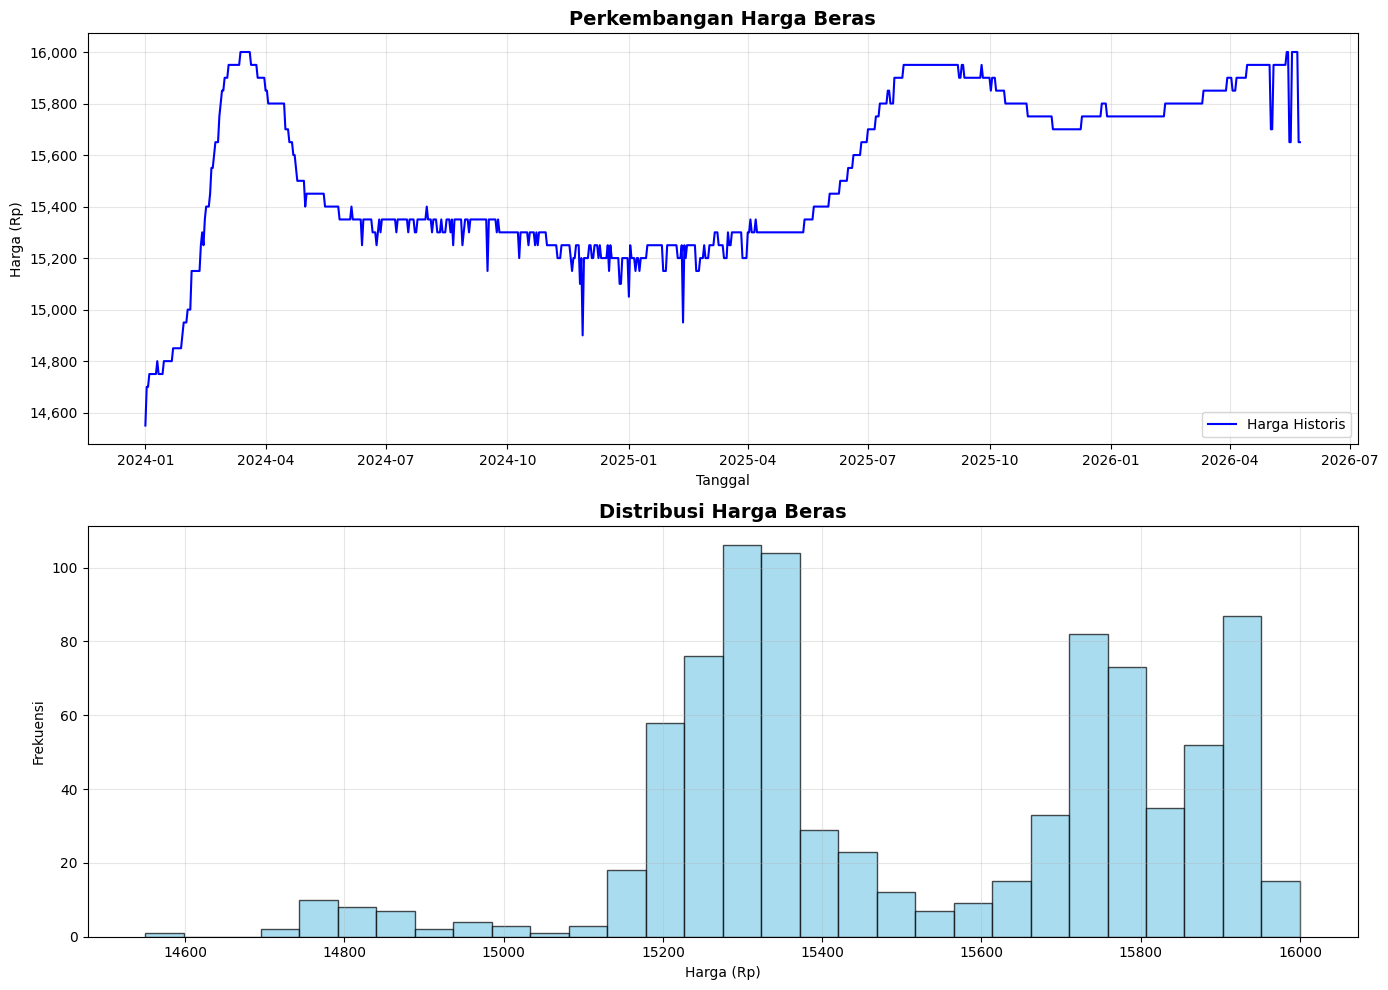

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Time series
axes[0].plot(df['date'], df['price'], 'b-', linewidth=1.5, label='Harga Historis')
axes[0].set_title(f'Perkembangan Harga {selected_commodity["name"]}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga (Rp)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format y-axis dengan separator ribuan
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot 2: Distribusi harga
axes[1].hist(df['price'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_title(f'Distribusi Harga {selected_commodity["name"]}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Harga (Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Data Untuk ELM

In [ ]:
print("\n" + "="*60)
print("PERSIAPAN DATA UNTUK MODEL ELM")
print("="*60)

# Parameter
look_back = 7  # Menggunakan 7 hari sebelumnya untuk prediksi
test_size = 0.2  # 20% data untuk testing
validation_size = 0.1  # 10% dari training untuk validation

# Normalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['price']].values)

# Buat sequences
X, y = create_sequences(scaled_data.flatten(), look_back)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Split data
split_idx = int(len(X) * (1 - test_size))
X_train_full, X_test = X[:split_idx], X[split_idx:]
y_train_full, y_test = y[:split_idx], y[split_idx:]

# Split training menjadi train dan validation
val_idx = int(len(X_train_full) * (1 - validation_size))
X_train, X_val = X_train_full[:val_idx], X_train_full[val_idx:]
y_train, y_val = y_train_full[:val_idx], y_train_full[val_idx:]

print(f"\nSplit data:")
print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")


PERSIAPAN DATA UNTUK MODEL ELM
Shape X: (868, 7)
Shape y: (868,)

Split data:
Training: 624 samples
Validation: 70 samples
Testing: 174 samples


#Model ELM

In [ ]:
print("\n" + "="*60)
print("PERSIAPAN DATA UNTUK MODEL ELM")
print("="*60)

# Parameter
look_back = 7  # Menggunakan 7 hari sebelumnya untuk prediksi
test_size = 0.2  # 20% data untuk testing
validation_size = 0.1  # 10% dari training untuk validation

# Normalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['price']].values)

# Buat sequences
X, y = create_sequences(scaled_data.flatten(), look_back)

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Split data
split_idx = int(len(X) * (1 - test_size))
X_train_full, X_test = X[:split_idx], X[split_idx:]
y_train_full, y_test = y[:split_idx], y[split_idx:]

# Split training menjadi train dan validation
val_idx = int(len(X_train_full) * (1 - validation_size))
X_train, X_val = X_train_full[:val_idx], X_train_full[val_idx:]
y_train, y_val = y_train_full[:val_idx], y_train_full[val_idx:]

print(f"\nSplit data:")
print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")

# ============================================
# MEMBANGUN MODEL ELM
# ============================================

print("\n" + "="*60)
print("MEMBANGUN MODEL EXTREME LEARNING MACHINE (ELM)")
print("="*60)

# Definisi fungsi untuk training dan evaluasi ELM
def train_elm_model(X_train, y_train, X_val, y_val, n_neurons_list):
    """
    Melatih model ELM dengan berbagai jumlah neuron dan memilih yang terbaik
    """
    results = []

    for neurons in n_neurons_list:
        # Inisialisasi ELM
        elm = ELM(X_train.shape[1], 1)  # Input: look_back features, Output: 1

        # Tambah hidden layer
        elm.add_neurons(neurons, 'sigm')  # Menggunakan fungsi aktivasi sigmoid

        # Training
        elm.train(X_train, y_train, 'r')  # 'r' untuk regression

        # Prediksi pada validation set
        y_val_pred = elm.predict(X_val)

        # Hitung error
        mse = mean_squared_error(y_val, y_val_pred)
        mae = mean_absolute_error(y_val, y_val_pred)

        results.append({
            'neurons': neurons,
            'mse': mse,
            'mae': mae,
            'model': elm
        })

        print(f"Neuron: {neurons:3d} | MSE: {mse:.6f} | MAE: {mae:.4f}")

    # Pilih model dengan MSE terendah
    best_model = min(results, key=lambda x: x['mse'])
    print(f"\nModel terbaik: {best_model['neurons']} neurons (MSE: {best_model['mse']:.6f})")

    return best_model['model'], best_model

# Coba berbagai jumlah neuron
n_neurons_list = [10, 20, 50, 100, 150, 200, 300, 500]
best_elm, best_result = train_elm_model(X_train, y_train, X_val, y_val, n_neurons_list)


PERSIAPAN DATA UNTUK MODEL ELM
Shape X: (868, 7)
Shape y: (868,)

Split data:
Training: 624 samples
Validation: 70 samples
Testing: 174 samples

MEMBANGUN MODEL EXTREME LEARNING MACHINE (ELM)
Neuron:  10 | MSE: 0.000138 | MAE: 0.0070
Neuron:  20 | MSE: 0.000135 | MAE: 0.0073
Neuron:  50 | MSE: 0.000149 | MAE: 0.0063
Neuron: 100 | MSE: 0.000193 | MAE: 0.0088
Neuron: 150 | MSE: 0.000339 | MAE: 0.0100
Neuron: 200 | MSE: 0.000711 | MAE: 0.0148
Covariance matrix is not full rank; solving with SVD (slow)
This happened because you have duplicated or too many neurons
Neuron: 300 | MSE: 0.000202 | MAE: 0.0101
Covariance matrix is not full rank; solving with SVD (slow)
This happened because you have duplicated or too many neurons
Neuron: 500 | MSE: 0.000254 | MAE: 0.0104

Model terbaik: 20 neurons (MSE: 0.000135)


#Evaluasi Model

In [ ]:
print("\n" + "="*60)
print("EVALUASI MODEL")
print("="*60)

# Prediksi pada test set
y_test_pred = best_elm.predict(X_test)

# Inverse transform ke skala asli
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_original = scaler.inverse_transform(y_test_pred)

# Metrik evaluasi
mse = mean_squared_error(y_test_original, y_test_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_test_pred_original)
mape = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100
r2 = r2_score(y_test_original, y_test_pred_original)

print(f"\nMetrik Evaluasi pada Test Set:")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


EVALUASI MODEL

Metrik Evaluasi pada Test Set:
MSE  : 2925.76
RMSE : 54.09
MAE  : 19.60
MAPE : 0.12%
R²   : 0.6250


#Visualisasi Hasil Prediksi

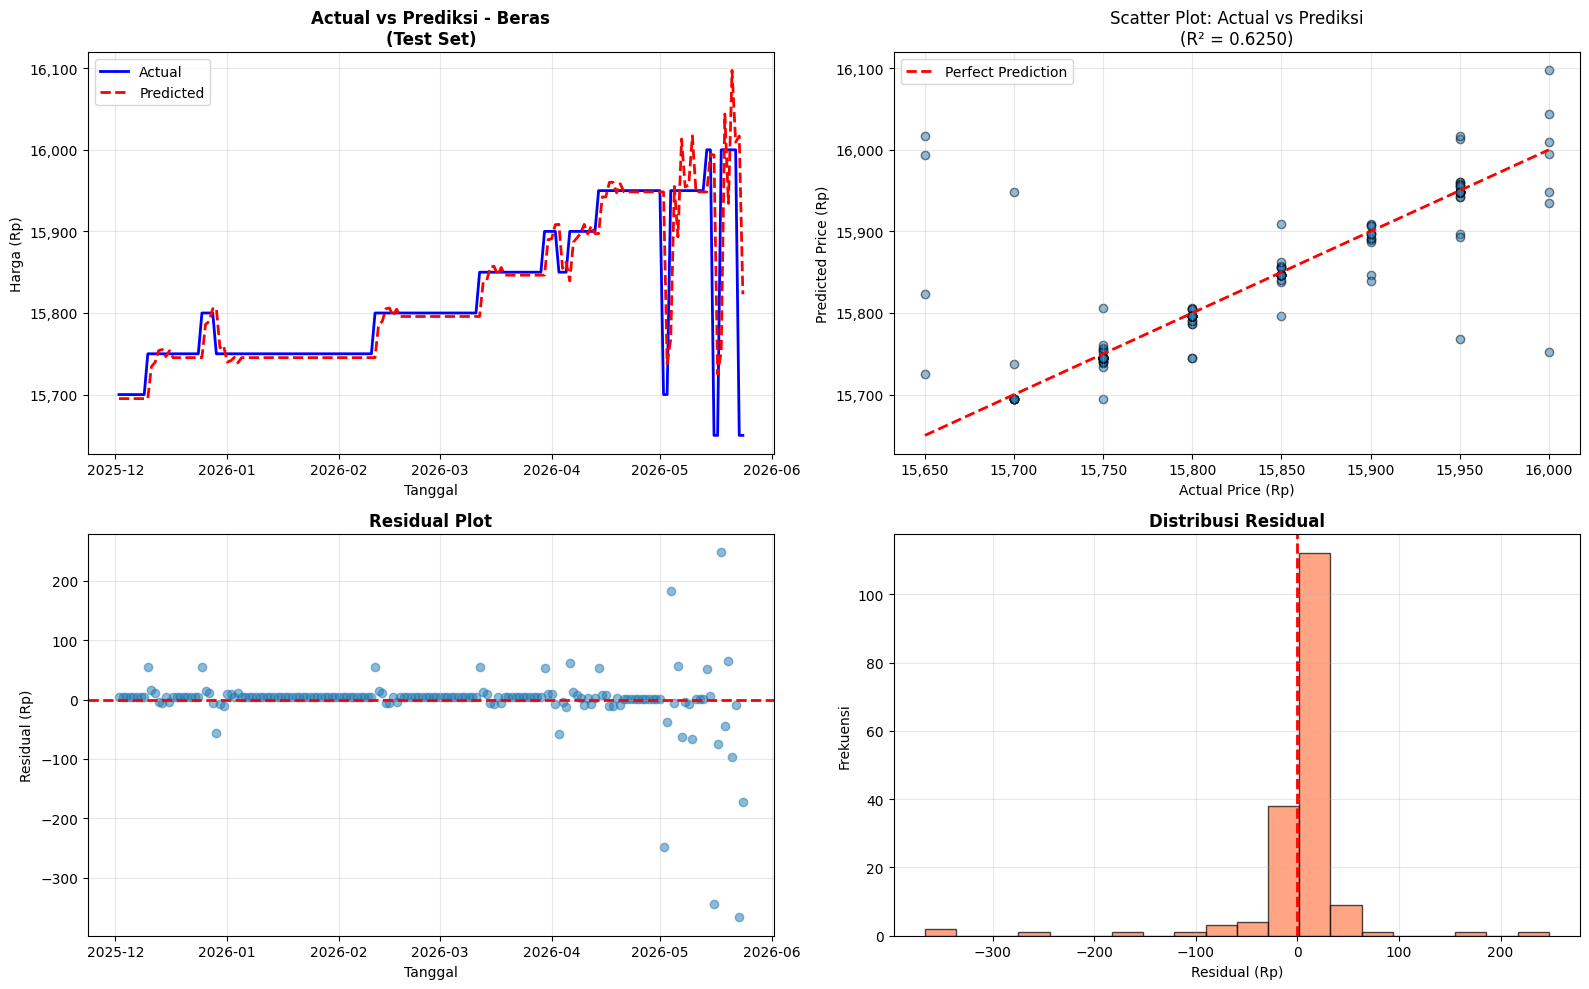

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Actual vs Prediksi (Test Set)
test_dates = df['date'].iloc[look_back:].iloc[split_idx:]
axes[0, 0].plot(test_dates, y_test_original, 'b-', label='Actual', linewidth=2)
axes[0, 0].plot(test_dates, y_test_pred_original, 'r--', label='Predicted', linewidth=2)
axes[0, 0].set_title(f'Actual vs Prediksi - {selected_commodity["name"]}\n(Test Set)',
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tanggal')
axes[0, 0].set_ylabel('Harga (Rp)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot 2: Scatter plot actual vs prediksi
axes[0, 1].scatter(y_test_original, y_test_pred_original, alpha=0.5, edgecolors='k')
axes[0, 1].plot([y_test_original.min(), y_test_original.max()],
                [y_test_original.min(), y_test_original.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price (Rp)')
axes[0, 1].set_ylabel('Predicted Price (Rp)')
axes[0, 1].set_title(f'Scatter Plot: Actual vs Prediksi\n(R² = {r2:.4f})', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot 3: Residual plot
residuals = y_test_original.flatten() - y_test_pred_original.flatten()
axes[1, 0].scatter(test_dates, residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tanggal')
axes[1, 0].set_ylabel('Residual (Rp)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Error distribution
axes[1, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Distribusi Residual', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residual (Rp)')
axes[1, 1].set_ylabel('Frekuensi')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Forecasting

In [ ]:
print("\n" + "="*60)
print("FORECASTING 30 HARI KE DEPAN")
print("="*60)

def forecast_future(model, last_sequence, scaler, n_days=30):
    """
    Melakukan forecasting untuk n hari ke depan
    """
    forecasts = []
    current_sequence = last_sequence.copy()

    for _ in range(n_days):
        # Prediksi nilai berikutnya
        next_value = model.predict(current_sequence.reshape(1, -1))
        forecasts.append(next_value[0, 0])

        # Update sequence
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = next_value[0, 0]

    # Inverse transform ke skala asli
    forecasts_original = scaler.inverse_transform(np.array(forecasts).reshape(-1, 1))

    return forecasts_original.flatten()

# Ambil sequence terakhir untuk forecasting
last_sequence = scaled_data[-look_back:].flatten()

# Forecast 30 hari ke depan
future_forecasts = forecast_future(best_elm, last_sequence, scaler, n_days=30)

# Buat tanggal untuk forecast
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Tampilkan hasil forecasting
print(f"\nPrediksi Harga {selected_commodity['name']} untuk 30 hari ke depan:")
print("-"*60)
print(f"{'Tanggal':<15} {'Prediksi Harga (Rp)':<20}")
print("-"*60)

for i, (date, price) in enumerate(zip(future_dates, future_forecasts), 1):
    print(f"{date.strftime('%Y-%m-%d'):<15} {price:>15,.0f}")


FORECASTING 30 HARI KE DEPAN

Prediksi Harga Beras untuk 30 hari ke depan:
------------------------------------------------------------
Tanggal         Prediksi Harga (Rp) 
------------------------------------------------------------
2026-05-25               15,770
2026-05-26               15,839
2026-05-27               15,893
2026-05-28               15,914
2026-05-29               15,864
2026-05-30               15,923
2026-05-31               15,974
2026-06-01               15,968
2026-06-02               15,979
2026-06-03               16,011
2026-06-04               16,003
2026-06-05               16,017
2026-06-06               16,040
2026-06-07               16,041
2026-06-08               16,041
2026-06-09               16,060
2026-06-10               16,063
2026-06-11               16,064
2026-06-12               16,076
2026-06-13               16,082
2026-06-14               16,083
2026-06-15               16,091
2026-06-16               16,098
2026-06-17               16,1

#Visualisasi Forecasting

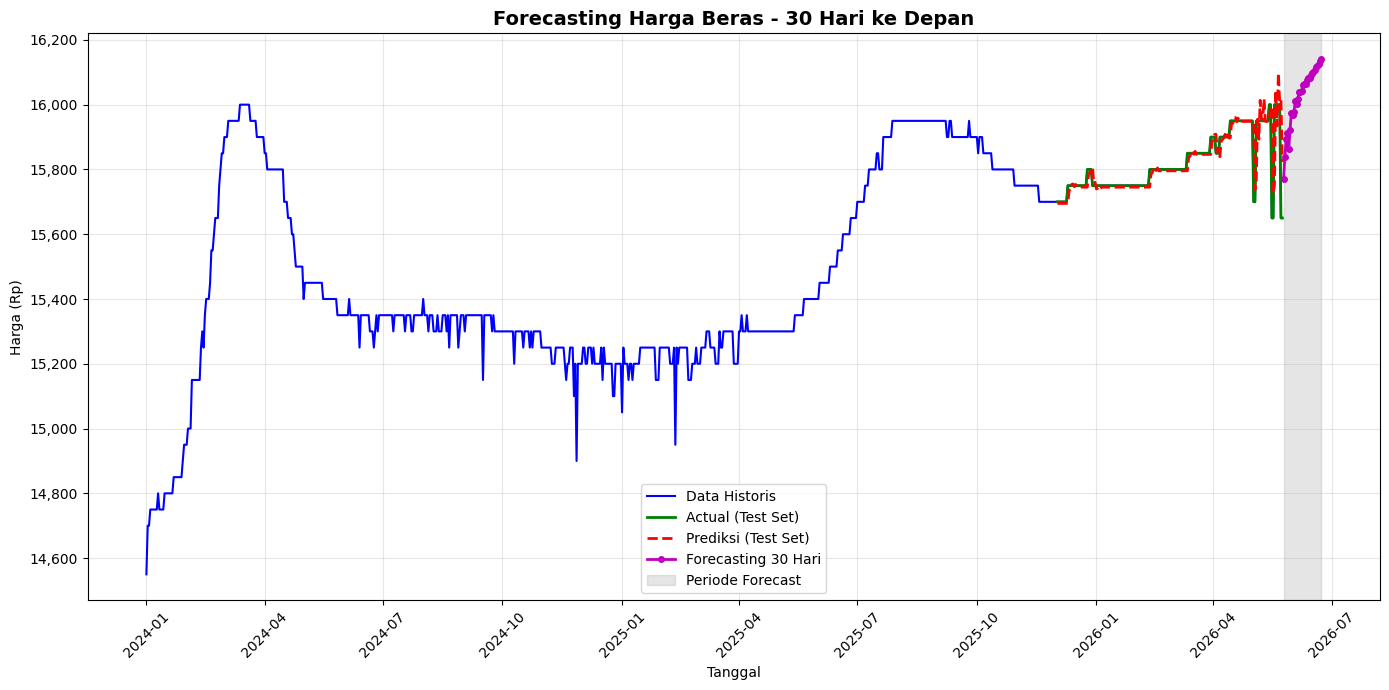

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot data historis
ax.plot(df['date'], df['price'], 'b-', label='Data Historis', linewidth=1.5)

# Plot hasil prediksi test set
test_start_idx = split_idx + look_back
test_actual_dates = df['date'].iloc[test_start_idx:]
ax.plot(test_actual_dates, y_test_original, 'g-', label='Actual (Test Set)', linewidth=2)
ax.plot(test_actual_dates, y_test_pred_original, 'r--', label='Prediksi (Test Set)', linewidth=2)

# Plot forecasting
ax.plot(future_dates, future_forecasts, 'm-', label='Forecasting 30 Hari', linewidth=2, marker='o', markersize=4)

# Tambahkan shade untuk area forecasting
ax.axvspan(future_dates[0], future_dates[-1], alpha=0.2, color='gray', label='Periode Forecast')

ax.set_title(f'Forecasting Harga {selected_commodity["name"]} - 30 Hari ke Depan',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Harga (Rp)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Rotate x-axis labels
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Save Model dan Hasil

In [ ]:
print("\n" + "="*60)
print("MENYIMPAN HASIL")
print("="*60)

# Simpan hasil forecasting ke CSV
forecast_df = pd.DataFrame({
    'date': future_dates,
    f'forecast_{selected_commodity["name"].replace(" ", "_")}': future_forecasts
})
forecast_df.to_csv('forecast_results.csv', index=False)
print("Hasil forecasting disimpan ke 'forecast_results.csv'")

# Simpan metrik evaluasi
evaluation_metrics = {
    'commodity': selected_commodity['name'],
    'mse': float(mse),
    'rmse': float(rmse),
    'mae': float(mae),
    'mape': float(mape),
    'r2': float(r2),
    'best_neurons': best_result['neurons'],
    'look_back': look_back
}

with open('evaluation_metrics.json', 'w') as f:
    json.dump(evaluation_metrics, f, indent=2)
print("Metrik evaluasi disimpan ke 'evaluation_metrics.json'")

print("\n" + "="*60)
print("PROSES SELESAI!")
print("="*60)